# 61b: Cross-Tabulation — Category × Emotion Interaction Analysis

Extends the event study by asking: do specific category-emotion combinations produce
systematically different financial outcomes? This tests whether Stage 1 (taxonomy) and
Stage 2 (emotion detection) together carry more information than either alone.

**Loading from**: `results/phase_iv/event_study_results_v3.parquet` produced by notebook 61v3.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('results/phase_iv')

event_df = pd.read_parquet(OUTPUT_DIR / 'event_study_results_v3.parquet')

CAT_ORDER = ['Governance', 'Communication', 'Legal', 'Personnel',
             'IT/Data', 'Products', 'Processes']
EMO_ORDER = ['fear', 'disgust', 'sadness', 'anger']

# Filter to valid rows only
df = event_df[
    event_df['primary_category'].isin(CAT_ORDER) &
    event_df['dominant_emotion'].isin(EMO_ORDER)
].copy()

print(f'Events for cross-tabulation: {len(df):,}')
print(f'\nCell counts (category × emotion):')
ct = pd.crosstab(df['primary_category'], df['dominant_emotion'])
ct = ct.reindex(index=CAT_ORDER, columns=EMO_ORDER, fill_value=0)
print(ct.to_string())
print(f'\nCells with n ≥ 10: {(ct >= 10).sum().sum()} / {ct.shape[0]*ct.shape[1]}')

Events for cross-tabulation: 1,463

Cell counts (category × emotion):
dominant_emotion  fear  disgust  sadness  anger
primary_category                               
Governance          91       81       67     61
Communication      155      122      155    144
Legal               40       38       36     83
Personnel           22       32       21     21
IT/Data             32       29       18     28
Products            29       18       24     13
Processes           37       20       30     16

Cells with n ≥ 10: 28 / 28


## Step 1 — Mean CAR heatmaps

Two heatmaps side by side:
- Left: mean CAR [-1,+5] by category × emotion (colour = magnitude)
- Right: cell count (to communicate which cells are reliable)

Cells with n < 10 are masked (hatched) to avoid over-interpretation.

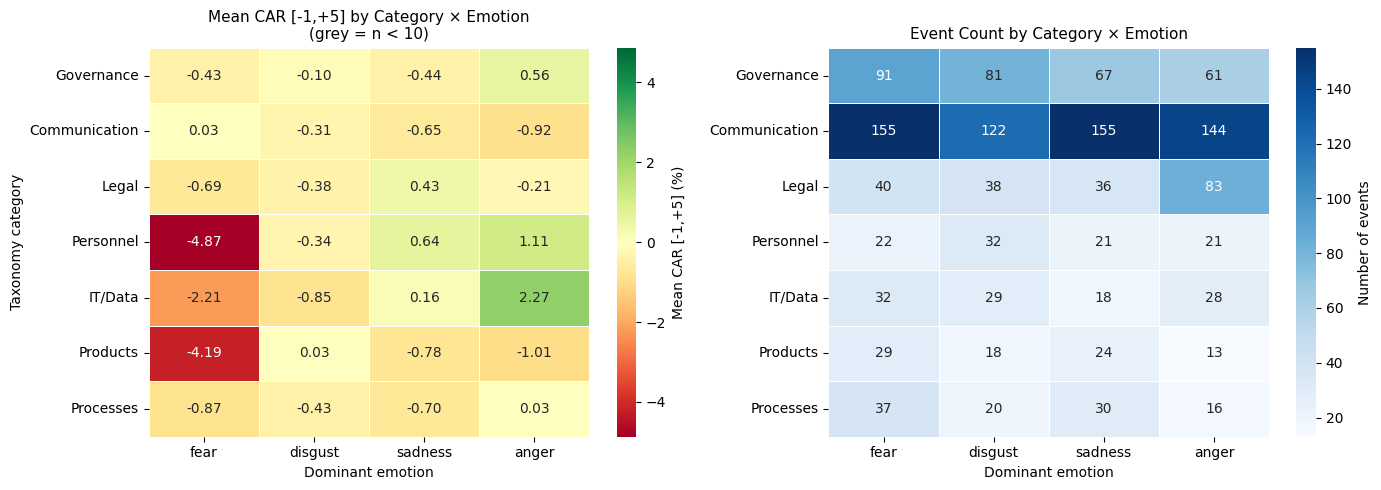

✓ Heatmap saved to results/phase_iv/crosstab_heatmap.png


In [2]:
# Build mean CAR and count matrices
car_matrix = (
    df.groupby(['primary_category', 'dominant_emotion'])['car']
    .mean()
    .unstack('dominant_emotion')
    .reindex(index=CAT_ORDER, columns=EMO_ORDER)
    * 100  # convert to %
)

n_matrix = (
    df.groupby(['primary_category', 'dominant_emotion'])['car']
    .count()
    .unstack('dominant_emotion')
    .reindex(index=CAT_ORDER, columns=EMO_ORDER, fill_value=0)
)

mask = n_matrix < 10  # mask unreliable cells

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: mean CAR heatmap ──────────────────────────────────────────────────
ax = axes[0]
vabs = max(abs(car_matrix.values[~np.isnan(car_matrix.values)])) if not car_matrix.isnull().all().all() else 2

sns.heatmap(
    car_matrix,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    vmin=-vabs, vmax=vabs,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    mask=mask,
    cbar_kws={'label': 'Mean CAR [-1,+5] (%)'}
)
# Hatch masked cells
for i in range(len(CAT_ORDER)):
    for j in range(len(EMO_ORDER)):
        if mask.iloc[i, j]:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1, fill=True,
                color='lightgrey', alpha=0.6, zorder=2
            ))
            ax.text(j + 0.5, i + 0.5, f'n={n_matrix.iloc[i,j]}',
                    ha='center', va='center', fontsize=8,
                    color='dimgrey', zorder=3)

ax.set_title('Mean CAR [-1,+5] by Category × Emotion\n(grey = n < 10)', fontsize=11)
ax.set_xlabel('Dominant emotion', fontsize=10)
ax.set_ylabel('Taxonomy category', fontsize=10)

# ── Right: sample size heatmap ──────────────────────────────────────────────
ax2 = axes[1]
sns.heatmap(
    n_matrix,
    ax=ax2,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=0.5,
    cbar_kws={'label': 'Number of events'}
)
ax2.set_title('Event Count by Category × Emotion', fontsize=11)
ax2.set_xlabel('Dominant emotion', fontsize=10)
ax2.set_ylabel('')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'crosstab_heatmap.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Heatmap saved to {fig_path}')

## Step 2 — Statistical tests for cells with sufficient n

For every category-emotion cell with n ≥ 10, we test whether mean CAR is
significantly negative using the Wilcoxon signed-rank test. Results are
collected into a table for paper reporting.

In [3]:
MIN_N = 10
sig = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))

from statsmodels.stats.multitest import multipletests

cell_results = []

for cat in CAT_ORDER:
    for emo in EMO_ORDER:
        sub = df[(df['primary_category'] == cat) & (df['dominant_emotion'] == emo)]['car'].dropna()
        n = len(sub)
        if n < MIN_N:
            continue
        mean_car  = sub.mean()
        pct_neg   = (sub < 0).mean() * 100
        _, wil_p  = stats.wilcoxon(sub, alternative='less')
        # One-sample t-test as complement
        t_stat, t_p = stats.ttest_1samp(sub, 0, alternative='less')

        cell_results.append({
            'Category'    : cat,
            'Emotion'     : emo,
            'n'           : n,
            'Mean CAR'    : mean_car,
            'Mean CAR %'  : f'{mean_car*100:+.3f}%',
            '% Negative'  : f'{pct_neg:.1f}%',
            'Wilcoxon p'  : wil_p,
            'Wilcoxon'    : f'{wil_p:.4f}{sig(wil_p)}',
            't-test p'    : t_p,
            't-test'      : f'{t_stat:+.3f} ({t_p:.4f}{sig(t_p)})',
        })

cell_df = pd.DataFrame(cell_results).sort_values('Mean CAR')

pvals = cell_df['Wilcoxon p'].to_numpy()
_, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
cell_df['Wilcoxon p (FDR)'] = pvals_fdr
cell_df['Raw sig'] = cell_df['Wilcoxon p'].apply(sig)
cell_df['FDR sig'] = cell_df['Wilcoxon p (FDR)'].apply(sig)

print(f'Cells with n ≥ {MIN_N}: {len(cell_df)}')
print()
print(cell_df[['Category','Emotion','n','Mean CAR %','% Negative',
               'Wilcoxon','t-test']].to_string(index=False))

cell_df.to_csv(OUTPUT_DIR / 'crosstab_results.csv', index=False)
print(f'\n✓ Saved to {OUTPUT_DIR / "crosstab_results.csv"}')
print('Note: * p<0.10  ** p<0.05  *** p<0.01  (one-sided H1: CAR < 0)')

Cells with n ≥ 10: 28

     Category Emotion   n Mean CAR % % Negative Wilcoxon             t-test
    Personnel    fear  22    -4.871%      63.6% 0.0138**    -1.292 (0.1052)
     Products    fear  29    -4.189%      55.2%  0.0504*  -1.709 (0.0492**)
      IT/Data    fear  32    -2.210%      59.4%  0.0575*  -1.768 (0.0434**)
     Products   anger  13    -1.008%      53.8%   0.2709    -0.660 (0.2609)
Communication   anger 144    -0.916%      54.9% 0.0165** -2.524 (0.0063***)
    Processes    fear  37    -0.866%      67.6% 0.0181**   -1.612 (0.0578*)
      IT/Data disgust  29    -0.853%      62.1%   0.1191    -0.842 (0.2034)
     Products sadness  24    -0.778%      45.8%   0.4167    -0.537 (0.2984)
    Processes sadness  30    -0.699%      53.3%   0.2261    -0.848 (0.2017)
        Legal    fear  40    -0.695%      65.0% 0.0265**    -0.914 (0.1833)
Communication sadness 155    -0.650%      52.9%   0.2159   -1.300 (0.0978*)
   Governance sadness  67    -0.441%      47.8%   0.5670    -0.62

In [4]:
cell_df[['Category', 'Emotion', 'n', 'Wilcoxon p', 'Wilcoxon p (FDR)', 'Raw sig', 'FDR sig']]

,Category,Emotion,n,Wilcoxon p,Wilcoxon p (FDR),Raw sig,FDR sig
12,Personnel,fear,22,0.013768,0.169292,**,
20,Products,fear,29,0.050432,0.268298,*,
16,IT/Data,fear,32,0.057492,0.268298,*,
23,Products,anger,13,0.270874,0.541748,,
7,Communication,anger,144,0.016507,0.169292,**,
24,Processes,fear,37,0.018138,0.169292,**,
17,IT/Data,disgust,29,0.119129,0.476517,,
22,Products,sadness,24,0.416687,0.648179,,
26,Processes,sadness,30,0.226082,0.527525,,
8,Legal,fear,40,0.026541,0.185789,**,


### Step 2A: SCCT test: pair-margin emotion classification (z-score basis)

> Methodological choice: the original prototype in notebook 61 classified peaks using mean raw emotion probabilities. This notebook uses **mean emotion z-scores** (`mean_anger_z`, `mean_disgust_z`, `mean_sadness_z`, `mean_fear_z`) from the saved peak-detection output as the primary basis for the pair-margin rule, so the classification is aligned with the Stage 2 peak signal definitions (`dominant_emotion`, `max_z`) and can be merged directly to the existing event-study results without reintroducing taxonomy categories.

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

OUTPUT_DIR = Path('results/phase_iv')
PEAKS_PATH = Path('results/phase_iii/all_peaks_loose_threshold.parquet')
EVENT_PATH = OUTPUT_DIR / 'event_study_results_v3.parquet'

PRIMARY_CAR_COL = 'car'
PRIMARY_CAR_LABEL = 'CAR [-1,+5]'
SECONDARY_CAR_COL = 'car_post'
CLASSIFICATION_BASIS = 'mean z-score'
CLASSIFICATION_NOTE = (
    'Primary analysis uses mean emotion z-scores from all_peaks (not raw mean probabilities) '
    'for the pair-margin rule. This keeps the SCCT assignment consistent with Stage 2 signal definitions '
    'such as dominant_emotion and max_z while remaining independent of Stage 1 taxonomy categories.'
)

NEGATIVE_Z_COLS = {
    'anger': 'mean_anger_z',
    'disgust': 'mean_disgust_z',
    'sadness': 'mean_sadness_z',
    'fear': 'mean_fear_z',
}
CLUSTER_ORDER = ['Preventable', 'Victim', 'Accidental']
PAIRWISE_ORDER = [
    ('Preventable', 'Victim', 'Preventable < Victim'),
    ('Preventable', 'Accidental', 'Preventable < Accidental'),
    ('Accidental', 'Victim', 'Accidental < Victim'),
]

all_peaks = pd.read_parquet(PEAKS_PATH).copy()
all_peaks['start_date'] = pd.to_datetime(all_peaks['start_date'])
all_peaks['end_date'] = pd.to_datetime(all_peaks['end_date'])

event_df = pd.read_parquet(EVENT_PATH).copy()
event_df['event_date'] = pd.to_datetime(event_df['event_date'])

required_peak_cols = ['peak_id', 'ticker', 'start_date', 'end_date', 'duration_days', 'max_z'] + list(NEGATIVE_Z_COLS.values())
missing_peak_cols = [c for c in required_peak_cols if c not in all_peaks.columns]
missing_event_cols = [c for c in ['peak_id', 'event_date', PRIMARY_CAR_COL, SECONDARY_CAR_COL, 'scar'] if c not in event_df.columns]
if missing_peak_cols:
    raise KeyError(f'Missing peak columns required for pair-margin classification: {missing_peak_cols}')
if missing_event_cols:
    raise KeyError(f'Missing event-study columns required for CAR analysis: {missing_event_cols}')

def classify_crisis_type(row, margin=1.2):
    anger_disgust = row[NEGATIVE_Z_COLS['anger']] + row[NEGATIVE_Z_COLS['disgust']]
    sadness_fear = row[NEGATIVE_Z_COLS['sadness']] + row[NEGATIVE_Z_COLS['fear']]
    if pd.isna(anger_disgust) or pd.isna(sadness_fear):
        return np.nan
    if anger_disgust <= 0 and sadness_fear <= 0:
        return 'Accidental'
    if anger_disgust > sadness_fear * margin:
        return 'Preventable'
    if sadness_fear > anger_disgust * margin:
        return 'Victim'
    return 'Accidental'

def bmp_test(scar_values):
    """
    Boehmer, Musumeci & Poulsen (1991) standardized cross-sectional test,
    aligned with notebook 61: takes each event's market-model
    forecast-error-adjusted standardized CAR (event_df['scar'], which
    already accounts for the uncertainty in estimated alpha/beta) and runs
    the cross-sectional t-test across events. One-sided, H1: mean SCAR < 0,
    matching the Wilcoxon/Mann-Whitney convention used elsewhere in this
    notebook.
    """
    scar = np.asarray(scar_values, dtype=float)
    scar = scar[~np.isnan(scar)]
    n = len(scar)
    if n < 2:
        return np.nan, np.nan
    mean_scar = scar.mean()
    std_scar = scar.std(ddof=1)
    t_stat = np.sqrt(n) * mean_scar / std_scar
    p_value = stats.t.cdf(t_stat, df=n - 1)
    return t_stat, p_value

def add_fdr(series):
    q = pd.Series(np.nan, index=series.index, dtype=float)
    mask = series.notna()
    if mask.any():
        q.loc[mask] = multipletests(series.loc[mask], method='fdr_bh')[1]
    return q

def build_classified_peaks(margin):
    classified = all_peaks[required_peak_cols].copy()
    classified['anger_disgust_score'] = (
        classified[NEGATIVE_Z_COLS['anger']] + classified[NEGATIVE_Z_COLS['disgust']]
    )
    classified['sadness_fear_score'] = (
        classified[NEGATIVE_Z_COLS['sadness']] + classified[NEGATIVE_Z_COLS['fear']]
    )
    classified['crisis_type'] = classified.apply(classify_crisis_type, axis=1, margin=margin)
    return classified

def merge_with_events(classified):
    merged = classified.merge(
        event_df[['peak_id', 'event_date', PRIMARY_CAR_COL, SECONDARY_CAR_COL, 'scar']],
        on='peak_id',
        how='left',
        validate='one_to_one'
    )
    merged['matched_event'] = merged['event_date'].notna()
    merged['has_primary_car'] = merged[PRIMARY_CAR_COL].notna()
    return merged

def cluster_distribution_table(df, label):
    counts = df['crisis_type'].value_counts().reindex(CLUSTER_ORDER, fill_value=0)
    total = counts.sum()
    out = pd.DataFrame({
        'sample': label,
        'crisis_type': counts.index,
        'n': counts.values,
        'pct': np.where(total > 0, counts.values / total * 100, np.nan),
    })
    out['pct'] = out['pct'].round(2)
    return out

def cluster_attrition_table(merged):
    out = (
        merged.groupby('crisis_type')
        .agg(
            classified_peaks=('peak_id', 'size'),
            matched_event_rows=('matched_event', 'sum'),
            usable_car_rows=('has_primary_car', 'sum'),
        )
        .reindex(CLUSTER_ORDER)
        .fillna(0)
        .astype(int)
        .reset_index()
    )
    out['match_rate_pct'] = (out['matched_event_rows'] / out['classified_peaks'] * 100).round(2)
    out['usable_car_rate_pct'] = (out['usable_car_rows'] / out['classified_peaks'] * 100).round(2)
    return out

def one_sample_cluster_table(sample):
    rows = []
    for cluster in CLUSTER_ORDER:
        sub = sample[(sample['crisis_type'] == cluster) & sample[PRIMARY_CAR_COL].notna()].copy()
        cars = sub[PRIMARY_CAR_COL].dropna()
        bmp_t, bmp_p = bmp_test(sub['scar'].values.astype(float)) if len(sub) else (np.nan, np.nan)
        wilcox_p = stats.wilcoxon(cars, alternative='less')[1] if len(cars) >= 10 else np.nan
        rows.append({
            'cluster': cluster,
            'n': len(cars),
            'mean_car_pct': cars.mean() * 100 if len(cars) else np.nan,
            'mean_car_post_pct': sub[SECONDARY_CAR_COL].mean() * 100 if len(sub) else np.nan,
            'pct_negative': (cars < 0).mean() * 100 if len(cars) else np.nan,
            'bmp_t': bmp_t,
            'bmp_p': bmp_p,
            'wilcoxon_p': wilcox_p,
        })
    out = pd.DataFrame(rows)
    out['wilcoxon_p_fdr'] = add_fdr(out['wilcoxon_p'])
    return out

def pairwise_table(sample):
    rows = []
    for left, right, alternative_label in PAIRWISE_ORDER:
        left_vals = sample.loc[(sample['crisis_type'] == left) & sample[PRIMARY_CAR_COL].notna(), PRIMARY_CAR_COL]
        right_vals = sample.loc[(sample['crisis_type'] == right) & sample[PRIMARY_CAR_COL].notna(), PRIMARY_CAR_COL]
        if len(left_vals) and len(right_vals):
            u_stat, p_val = stats.mannwhitneyu(left_vals, right_vals, alternative='less')
        else:
            u_stat, p_val = np.nan, np.nan
        rows.append({
            'comparison': f'{left} vs {right}',
            'alternative': alternative_label,
            'n_left': len(left_vals),
            'mean_left_pct': left_vals.mean() * 100 if len(left_vals) else np.nan,
            'n_right': len(right_vals),
            'mean_right_pct': right_vals.mean() * 100 if len(right_vals) else np.nan,
            'mean_diff_pp': ((left_vals.mean() - right_vals.mean()) * 100) if len(left_vals) and len(right_vals) else np.nan,
            'u_stat': u_stat,
            'raw_p': p_val,
        })
    out = pd.DataFrame(rows)
    out['fdr_p'] = add_fdr(out['raw_p'])
    return out

def omnibus_test(sample):
    groups = [
        sample.loc[(sample['crisis_type'] == cluster) & sample[PRIMARY_CAR_COL].notna(), PRIMARY_CAR_COL]
        for cluster in CLUSTER_ORDER
    ]
    if min(len(group) for group in groups) == 0:
        return np.nan, np.nan
    return stats.kruskal(*groups)

def format_cluster_table(df):
    out = df.copy()
    out['mean_car_pct'] = out['mean_car_pct'].map(lambda x: f'{x:+.3f}%' if pd.notna(x) else 'nan')
    out['mean_car_post_pct'] = out['mean_car_post_pct'].map(lambda x: f'{x:+.3f}%' if pd.notna(x) else 'nan')
    out['pct_negative'] = out['pct_negative'].map(lambda x: f'{x:.1f}%' if pd.notna(x) else 'nan')
    for col in ['bmp_t', 'bmp_p', 'wilcoxon_p', 'wilcoxon_p_fdr']:
        out[col] = out[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')
    return out

def format_pairwise_table(df):
    out = df.copy()
    for col in ['mean_left_pct', 'mean_right_pct', 'mean_diff_pp']:
        out[col] = out[col].map(lambda x: f'{x:+.3f}%' if pd.notna(x) else 'nan')
    for col in ['u_stat', 'raw_p', 'fdr_p']:
        out[col] = out[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')
    return out

def run_analysis(margin=1.2, sample_label='main', sample_filter=None):
    classified = build_classified_peaks(margin)
    merged = merge_with_events(classified)
    if sample_filter is not None:
        merged = merged.loc[sample_filter(merged)].copy()
    cluster_dist = cluster_distribution_table(classified, f'all peaks (margin={margin})')
    sample_dist = cluster_distribution_table(merged[merged['has_primary_car']], f'event-study sample ({sample_label})')
    attrition = cluster_attrition_table(merged)
    usable = merged[merged['has_primary_car']].copy()
    cluster_table = one_sample_cluster_table(usable)
    pairwise = pairwise_table(usable)
    kw_stat, kw_p = omnibus_test(usable)
    return {
        'classified': classified,
        'merged': merged,
        'cluster_distribution': cluster_dist,
        'sample_distribution': sample_dist,
        'attrition': attrition,
        'cluster_table': cluster_table,
        'pairwise_table': pairwise,
        'kw_stat': kw_stat,
        'kw_p': kw_p,
    }

main_results = run_analysis(margin=1.2, sample_label='main')
robust_results = run_analysis(
    margin=1.2,
    sample_label='excluding 2008-2009',
    sample_filter=lambda frame: frame['event_date'].dt.year >= 2010,
    )

sensitivity_rows = []
for margin in [1.1, 1.2, 1.5]:
    result = run_analysis(margin=margin, sample_label=f'margin={margin}')
    pv_row = result['pairwise_table'].loc[result['pairwise_table']['comparison'] == 'Preventable vs Victim'].iloc[0]
    sensitivity_rows.append({
        'margin': margin,
        'preventable_n': int(pv_row['n_left']),
        'victim_n': int(pv_row['n_right']),
        'preventable_minus_victim_pp': pv_row['mean_diff_pp'],
        'u_stat': pv_row['u_stat'],
        'raw_p': pv_row['raw_p'],
    })
sensitivity_df = pd.DataFrame(sensitivity_rows)

pair_margin_cluster_distribution = pd.concat([
    main_results['cluster_distribution'],
    main_results['sample_distribution'],
], ignore_index=True)
pair_margin_cluster_attrition = main_results['attrition']
pair_margin_main_cluster_table = main_results['cluster_table']
pair_margin_main_pairwise_table = main_results['pairwise_table']
pair_margin_robust_cluster_table = robust_results['cluster_table']
pair_margin_robust_pairwise_table = robust_results['pairwise_table']
pair_margin_sensitivity_table = sensitivity_df

pair_margin_cluster_distribution.to_csv(OUTPUT_DIR / 'scct_pair_margin_cluster_distribution.csv', index=False)
pair_margin_cluster_attrition.to_csv(OUTPUT_DIR / 'scct_pair_margin_cluster_attrition.csv', index=False)
pair_margin_main_cluster_table.to_csv(OUTPUT_DIR / 'scct_pair_margin_main_cluster_table.csv', index=False)
pair_margin_main_pairwise_table.to_csv(OUTPUT_DIR / 'scct_pair_margin_main_pairwise_table.csv', index=False)
pair_margin_robust_cluster_table.to_csv(OUTPUT_DIR / 'scct_pair_margin_robust_cluster_table.csv', index=False)
pair_margin_robust_pairwise_table.to_csv(OUTPUT_DIR / 'scct_pair_margin_robust_pairwise_table.csv', index=False)
pair_margin_sensitivity_table.to_csv(OUTPUT_DIR / 'scct_pair_margin_sensitivity.csv', index=False)

print('=' * 80)
print('SCCT PAIR-MARGIN ANALYSIS (emotion-only classification)')
print('=' * 80)
print(f'Classification basis: {CLASSIFICATION_BASIS}')
print(CLASSIFICATION_NOTE)
print(f'Primary CAR variable: {PRIMARY_CAR_COL} ({PRIMARY_CAR_LABEL})')
print()
print('Merge diagnostics')
print(f"  Classified peaks before merge: {len(main_results['classified']):,}")
print(f"  Rows after merge:              {len(main_results['merged']):,}")
print(f"  Peaks matched to event study:  {int(main_results['merged']['matched_event'].sum()):,}")
print(f"  Peaks with usable {PRIMARY_CAR_LABEL}: {int(main_results['merged']['has_primary_car'].sum()):,}")
print()
print(pair_margin_cluster_attrition.to_string(index=False))
print()
print('Cluster distribution')
print(pair_margin_cluster_distribution.to_string(index=False))
print()
print('Main sample: one-sample cluster tests')
print(format_cluster_table(pair_margin_main_cluster_table).to_string(index=False))
print()
print(f"Omnibus Kruskal-Wallis across clusters: H={main_results['kw_stat']:.4f}, p={main_results['kw_p']:.4f}")
print()
print('Main sample: pairwise Mann-Whitney tests (one-sided, first group more negative)')
print(format_pairwise_table(pair_margin_main_pairwise_table).to_string(index=False))
print()
print('Robustness check: exclude 2008-2009')
print(format_cluster_table(pair_margin_robust_cluster_table).to_string(index=False))
print()
print(f"Robustness omnibus Kruskal-Wallis: H={robust_results['kw_stat']:.4f}, p={robust_results['kw_p']:.4f}")
print()
print(format_pairwise_table(pair_margin_robust_pairwise_table).to_string(index=False))
print()
print('Margin sensitivity: Preventable vs Victim')
sensitivity_display = sensitivity_df.copy()
sensitivity_display['preventable_minus_victim_pp'] = sensitivity_display['preventable_minus_victim_pp'].map(lambda x: f'{x:+.3f}%' if pd.notna(x) else 'nan')
sensitivity_display['u_stat'] = sensitivity_display['u_stat'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')
sensitivity_display['raw_p'] = sensitivity_display['raw_p'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')
print(sensitivity_display.to_string(index=False))
print()

pv_row = pair_margin_main_pairwise_table.loc[
    pair_margin_main_pairwise_table['comparison'] == 'Preventable vs Victim'
].iloc[0]
prev_mean = pv_row['mean_left_pct']
vict_mean = pv_row['mean_right_pct']
direction = 'more negative than' if prev_mean < vict_mean else 'less negative than' if prev_mean > vict_mean else 'equal to'
significance = 'significant' if pv_row['raw_p'] < 0.05 else 'not significant'
comparison_with_old = (
    'contradicts the direction from the category × emotion cell-mapping result'
    if prev_mean < vict_mean else
    'matches the direction from the category × emotion cell-mapping result'
 )
summary_text = (
    f"Using {CLASSIFICATION_BASIS} pair-margin classification at margin 1.2, the full peak set splits into "
    f"{', '.join([f'{row.crisis_type} {int(row.n)} ({row.pct:.1f}%)' for row in pair_margin_cluster_distribution[pair_margin_cluster_distribution['sample'].eq('all peaks (margin=1.2)')].itertuples()])}. "
    f"After merging to the event-study sample, {int(main_results['merged']['has_primary_car'].sum())} peaks retain usable {PRIMARY_CAR_LABEL} values. "
    f"The omnibus Kruskal-Wallis test across Preventable, Victim, and Accidental CARs yields H={main_results['kw_stat']:.3f}, p={main_results['kw_p']:.4f}. "
    f"For Preventable vs Victim, Preventable is {direction} Victim ({prev_mean:+.3f}% vs {vict_mean:+.3f}%; U={pv_row['u_stat']:.1f}, p={pv_row['raw_p']:.4f}, q={pv_row['fdr_p']:.4f}), so the result is {significance} and {comparison_with_old}, which previously reported Preventable +0.266% vs Victim -0.654% (p=0.752). "
    f"This notebook explicitly uses mean emotion z-scores rather than raw mean probabilities so the SCCT cluster assignment is described consistently with the rest of Stage 2."
)
print('Summary for manuscript update')
print(summary_text)

with open(OUTPUT_DIR / 'scct_pair_margin_summary.txt', 'w') as handle:
    handle.write(summary_text + '\n')

small_clusters = pair_margin_main_cluster_table.loc[pair_margin_main_cluster_table['n'] < 10, 'cluster'].tolist()
if small_clusters:
    print()
    print(f"Data issue flag: small event-study clusters with n < 10 -> {', '.join(small_clusters)}")

print()
print('Saved outputs:')
for path in [
    OUTPUT_DIR / 'scct_pair_margin_cluster_distribution.csv',
    OUTPUT_DIR / 'scct_pair_margin_cluster_attrition.csv',
    OUTPUT_DIR / 'scct_pair_margin_main_cluster_table.csv',
    OUTPUT_DIR / 'scct_pair_margin_main_pairwise_table.csv',
    OUTPUT_DIR / 'scct_pair_margin_robust_cluster_table.csv',
    OUTPUT_DIR / 'scct_pair_margin_robust_pairwise_table.csv',
    OUTPUT_DIR / 'scct_pair_margin_sensitivity.csv',
    OUTPUT_DIR / 'scct_pair_margin_summary.txt',
]:
    print(f'  - {path}')

SCCT PAIR-MARGIN ANALYSIS (emotion-only classification)
Classification basis: mean z-score
Primary analysis uses mean emotion z-scores from all_peaks (not raw mean probabilities) for the pair-margin rule. This keeps the SCCT assignment consistent with Stage 2 signal definitions such as dominant_emotion and max_z while remaining independent of Stage 1 taxonomy categories.
Primary CAR variable: car (CAR [-1,+5])

Merge diagnostics
  Classified peaks before merge: 1,774
  Rows after merge:              1,774
  Peaks matched to event study:  1,463
  Peaks with usable CAR [-1,+5]: 1,463

crisis_type  classified_peaks  matched_event_rows  usable_car_rows  match_rate_pct  usable_car_rate_pct
Preventable               876                 717              717           81.85                81.85
     Victim               754                 621              621           82.36                82.36
 Accidental               144                 125              125           86.81                

## Step 3 — Do Stage 1 and Stage 2 jointly explain more than either alone?

OLS regression: CAR ~ category FE + emotion FE + category×emotion interaction.
The interaction term tests whether the joint signal from Stage 1 and Stage 2
explains variation beyond additive effects of each stage separately.

In [6]:
# F-tests — re-fit without HC3 since anova_lm requires standard OLS
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

reg_df = df[['car', 'primary_category', 'dominant_emotion',
             'max_z', 'duration_days']].dropna().copy()

mA_ = smf.ols('car ~ C(primary_category)', data=reg_df).fit()
mB_ = smf.ols('car ~ C(dominant_emotion)', data=reg_df).fit()
mC_ = smf.ols('car ~ C(primary_category) + C(dominant_emotion)', data=reg_df).fit()
mD_ = smf.ols('car ~ C(primary_category) * C(dominant_emotion)', data=reg_df).fit()

f_test_AC = anova_lm(mA_, mC_)  # Does emotion add to category?
f_test_BC = anova_lm(mB_, mC_)  # Does category add to emotion?
f_test_CD = anova_lm(mC_, mD_)  # Does interaction add to additive?

sig = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))

def print_ftest(label, result):
    f_val = result['F'].iloc[1]
    p_val = result['Pr(>F)'].iloc[1]
    df_num = int(result['df_diff'].iloc[1])
    print(f'  {label}')
    print(f'    F({df_num}) = {f_val:.3f},  p = {p_val:.4f}{sig(p_val)}')

print('\nF-tests (incremental fit):')
print_ftest('A → C: does emotion add to category?',   f_test_AC)
print_ftest('B → C: does category add to emotion?',   f_test_BC)
print_ftest('C → D: does interaction add to additive?', f_test_CD)

# Save all four models
with open(OUTPUT_DIR / 'regression_interaction.txt', 'w') as f:
    for label, m in [('A: Category only', mA_), ('B: Emotion only', mB_), ('C: Category + Emotion', mC_), ('D: Category × Emotion', mD_)]:
        f.write(f'\nMODEL {label}\n{"="*60}\n')
        f.write(m.summary().as_text())
        f.write('\n')
print('✓ Regression results saved')


F-tests (incremental fit):
  A → C: does emotion add to category?
    F(3) = 1.464,  p = 0.2226
  B → C: does category add to emotion?
    F(6) = 1.014,  p = 0.4147
  C → D: does interaction add to additive?
    F(18) = 1.823,  p = 0.0185**
✓ Regression results saved


In [7]:
print('Model comparison: R²')
print(f'  A — Category only       : R² = {mA_.rsquared:.4f},  adj R² = {mA_.rsquared_adj:.4f}')
print(f'  B — Emotion only        : R² = {mB_.rsquared:.4f},  adj R² = {mB_.rsquared_adj:.4f}')
print(f'  C — Category + Emotion  : R² = {mC_.rsquared:.4f},  adj R² = {mC_.rsquared_adj:.4f}')
print(f'  D — + Interaction       : R² = {mD_.rsquared:.4f},  adj R² = {mD_.rsquared_adj:.4f}')

Model comparison: R²
  A — Category only       : R² = 0.0045,  adj R² = 0.0004
  B — Emotion only        : R² = 0.0033,  adj R² = 0.0013
  C — Category + Emotion  : R² = 0.0075,  adj R² = 0.0013
  D — + Interaction       : R² = 0.0297,  adj R² = 0.0114


In [8]:
# HC3 fits for coefficient-level inference
mA = smf.ols('car ~ C(primary_category)', data=reg_df).fit(cov_type='HC3')
mB = smf.ols('car ~ C(dominant_emotion)', data=reg_df).fit(cov_type='HC3')
mC = smf.ols('car ~ C(primary_category) + C(dominant_emotion)', data=reg_df).fit(cov_type='HC3')
mD = smf.ols('car ~ C(primary_category) * C(dominant_emotion)', data=reg_df).fit(cov_type='HC3')

# Display and save regression summaries with HC3 SEs
with open(OUTPUT_DIR / 'regression_hc3.txt', 'w') as f:
    for label, m in [('A: Category only', mA), ('B: Emotion only', mB), ('C: Category + Emotion', mC), ('D: Category × Emotion', mD)]:
        f.write(f'\nMODEL {label} (HC3 SEs)\n{"="*60}\n')
        f.write(m.summary().as_text())
        f.write('\n')
print('✓ HC3 regression results saved')

# Display HC3 regression results
print('\nRegression results with HC3 SEs:')
for label, m in [('A: Category only', mA), ('B: Emotion only', mB), ('C: Category + Emotion', mC), ('D: Category × Emotion', mD)]:
    print(f'\nMODEL {label} (HC3 SEs)\n{"="*60}')
    print(m.summary()) 

✓ HC3 regression results saved

Regression results with HC3 SEs:

MODEL A: Category only (HC3 SEs)
                            OLS Regression Results                            
Dep. Variable:                    car   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                    0.6422
Date:                Thu, 13 Aug 2026   Prob (F-statistic):              0.697
Time:                        13:36:57   Log-Likelihood:                 2105.2
No. Observations:                1463   AIC:                            -4196.
Df Residuals:                    1456   BIC:                            -4159.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
---------

## Step 4 — CAR trajectory plot for key cells

For the paper figure: daily CAR accumulation for the four most
theoretically interesting and numerically populated category-emotion cells.

Selected cells for trajectory plot:
     Category Emotion   n Mean CAR % Wilcoxon
    Personnel    fear  22    -4.871% 0.0138**
     Products    fear  29    -4.189%  0.0504*
      IT/Data    fear  32    -2.210%  0.0575*
Communication   anger 144    -0.916% 0.0165**
    Processes    fear  37    -0.866% 0.0181**
      IT/Data disgust  29    -0.853%   0.1191


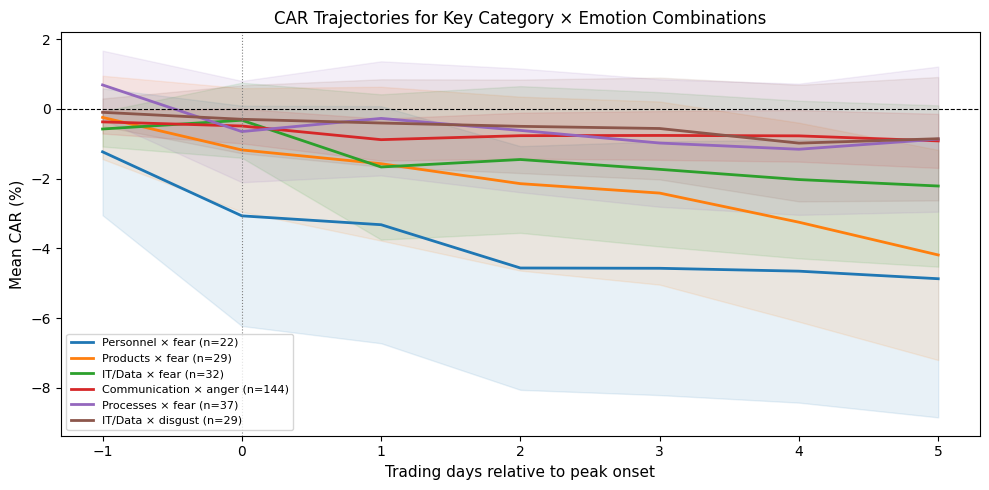

✓ Trajectory plot saved to results/phase_iv/crosstab_trajectories.png


In [9]:
ar_cols    = [c for c in event_df.columns if c.startswith('ar_day_')]
day_labels = list(range(-1, 6))  # [-1, +5]

# Pick cells with n ≥ 15 AND mean CAR most negative
eligible = cell_df[cell_df['n'] >= 15].nsmallest(6, 'Mean CAR')
print('Selected cells for trajectory plot:')
print(eligible[['Category','Emotion','n','Mean CAR %','Wilcoxon']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))

palette = plt.cm.tab10.colors

for idx, (_, row) in enumerate(eligible.iterrows()):
    sub = df[
        (df['primary_category'] == row['Category']) &
        (df['dominant_emotion']  == row['Emotion'])
    ]
    ar_mat  = event_df.loc[sub.index, ar_cols].values.astype(float)
    mean_ar = np.nanmean(ar_mat, axis=0)
    cum_car = np.nancumsum(mean_ar)
    n_valid = np.sum(~np.isnan(ar_mat), axis=0)
    se      = np.nanstd(ar_mat, axis=0, ddof=1) / np.sqrt(np.maximum(n_valid, 1))
    cum_se  = np.sqrt(np.nancumsum(se ** 2))

    label = f"{row['Category']} × {row['Emotion']} (n={row['n']})"
    colour = palette[idx]

    ax.plot(day_labels, cum_car * 100, color=colour, lw=2, label=label)
    ax.fill_between(day_labels,
                    (cum_car - 1.96 * cum_se) * 100,
                    (cum_car + 1.96 * cum_se) * 100,
                    alpha=0.10, color=colour)

ax.axhline(0,  color='black', lw=0.8, ls='--')
ax.axvline(0,  color='grey',  lw=0.8, ls=':')
ax.set_xlabel('Trading days relative to peak onset', fontsize=11)
ax.set_ylabel('Mean CAR (%)', fontsize=11)
ax.set_title('CAR Trajectories for Key Category × Emotion Combinations', fontsize=12)
ax.legend(fontsize=8, loc='lower left')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
traj_path = OUTPUT_DIR / 'crosstab_trajectories.png'
plt.savefig(traj_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Trajectory plot saved to {traj_path}')

## Step 5 — Paper table: cross-tabulation of mean CARs

Clean LaTeX-ready table for the paper.

In [10]:
# Pivot: rows = categories, cols = emotions, values = CAR% with raw and FDR-corrected p-values
def format_cell(cat, emo, cell_df):
    row = cell_df[(cell_df['Category'] == cat) & (cell_df['Emotion'] == emo)]
    n   = n_matrix.loc[cat, emo] if cat in n_matrix.index and emo in n_matrix.columns else 0
    if len(row) == 0 or n < MIN_N:
        return f'— (n={n})'
    r = row.iloc[0]
    return (
        f"{r['Mean CAR %']} (n={n}; p={r['Wilcoxon p']:.4f}{r['Raw sig']}; "
        f"q={r['Wilcoxon p (FDR)']:.4f}{r['FDR sig']})"
    )

table_rows = []
for cat in CAT_ORDER:
    row = {'Category': cat}
    for emo in EMO_ORDER:
        row[emo.capitalize()] = format_cell(cat, emo, cell_df)
    table_rows.append(row)

paper_ct = pd.DataFrame(table_rows).set_index('Category')
print('Cross-tabulation: Mean CAR [-1,+5] by Category × Emotion')
print('(— = n < 10; p = raw Wilcoxon p-value; q = FDR-corrected p-value; one-sided H1: CAR < 0)')
print()
print(paper_ct.to_string())

paper_ct.to_csv(OUTPUT_DIR / 'crosstab_paper_table.csv')

latex = paper_ct.to_latex(
    caption='Mean Cumulative Abnormal Returns (\\%) by Taxonomy Category and Dominant Emotion',
    label='tab:crosstab',
    escape=False
)
with open(OUTPUT_DIR / 'crosstab_paper_table.tex', 'w') as f:
    f.write(latex)
print('\n✓ Table saved (CSV + LaTeX)')

Cross-tabulation: Mean CAR [-1,+5] by Category × Emotion
(— = n < 10; p = raw Wilcoxon p-value; q = FDR-corrected p-value; one-sided H1: CAR < 0)

                                               Fear                              Disgust                              Sadness                                  Anger
Category                                                                                                                                                            
Governance       -0.429% (n=91; p=0.3360; q=0.6271)   -0.098% (n=81; p=0.2664; q=0.5417)   -0.441% (n=67; p=0.5670; q=0.6938)     +0.563% (n=61; p=0.8725; q=0.9111)
Communication   +0.025% (n=155; p=0.4552; q=0.6526)  -0.311% (n=122; p=0.1549; q=0.5275)  -0.650% (n=155; p=0.2159; q=0.5275)  -0.916% (n=144; p=0.0165**; q=0.1693)
Legal          -0.695% (n=40; p=0.0265**; q=0.1858)   -0.382% (n=38; p=0.2064; q=0.5275)   +0.428% (n=36; p=0.5031; q=0.6708)     -0.210% (n=83; p=0.3736; q=0.6458)
Personnel      -4.871% (n=22

## Step 6: FDR Correction

In [11]:
print(cell_df[['Category','Emotion','n','Mean CAR %','Wilcoxon p','Wilcoxon p (FDR)','Raw sig','FDR sig']]
      .sort_values('Wilcoxon p').to_string(index=False))

     Category Emotion   n Mean CAR %  Wilcoxon p  Wilcoxon p (FDR) Raw sig FDR sig
    Personnel    fear  22    -4.871%    0.013768          0.169292      **        
Communication   anger 144    -0.916%    0.016507          0.169292      **        
    Processes    fear  37    -0.866%    0.018138          0.169292      **        
        Legal    fear  40    -0.695%    0.026541          0.185789      **        
     Products    fear  29    -4.189%    0.050432          0.268298       *        
      IT/Data    fear  32    -2.210%    0.057492          0.268298       *        
      IT/Data disgust  29    -0.853%    0.119129          0.476517                
Communication disgust 122    -0.311%    0.154907          0.527525                
        Legal disgust  38    -0.382%    0.206378          0.527525                
Communication sadness 155    -0.650%    0.215919          0.527525                
    Personnel disgust  32    -0.336%    0.215972          0.527525                
    